1. Loading Iris dataset...
2. Engineering new morphological features...

Dataset Shape: (150, 10)

First 5 Rows with Engineered Features:


,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area,petal_area,sepal_ratio,petal_ratio,petal_to_sepal_area_ratio
0,5.1,3.5,1.4,0.2,setosa,17.85,0.28,1.457143,7.0,0.015686
1,4.9,3.0,1.4,0.2,setosa,14.70,0.28,1.633333,7.0,0.019048
2,4.7,3.2,1.3,0.2,setosa,15.04,0.26,1.468750,6.5,0.017287
3,4.6,3.1,1.5,0.2,setosa,14.26,0.30,1.483871,7.5,0.021038
4,5.0,3.6,1.4,0.2,setosa,18.00,0.28,1.388889,7.0,0.015556



3. Training and benchmark evaluation...

--- Logistic Regression ---
Test Accuracy: 100.00%
5-Fold Cross-Validation Accuracy: 97.33%

--- K-Nearest Neighbors ---
Test Accuracy: 96.67%
5-Fold Cross-Validation Accuracy: 96.67%

--- Random Forest ---
Test Accuracy: 96.67%
5-Fold Cross-Validation Accuracy: 96.00%

 Detailed Performance Report: Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



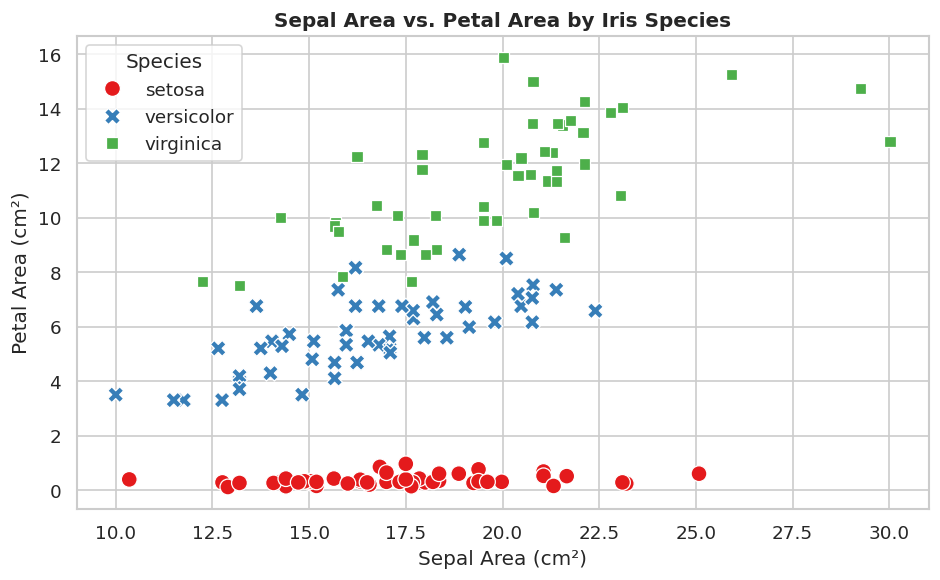

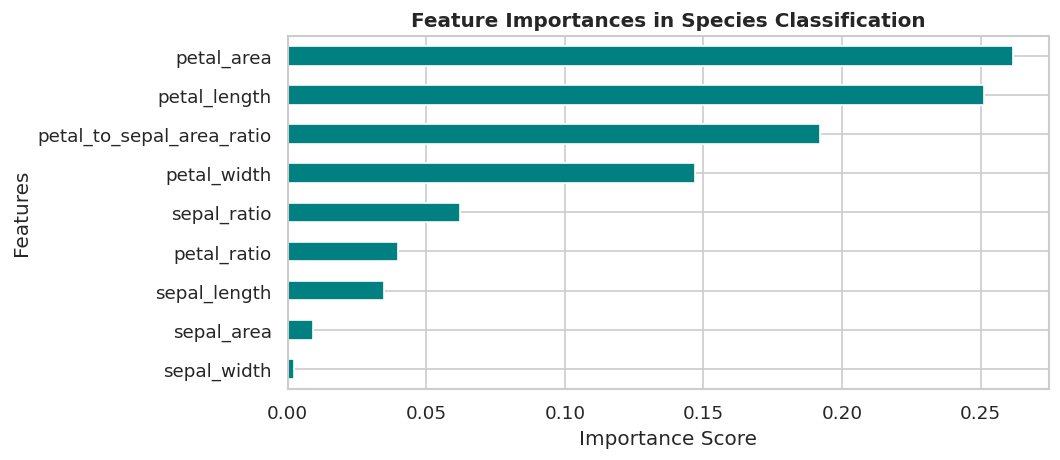

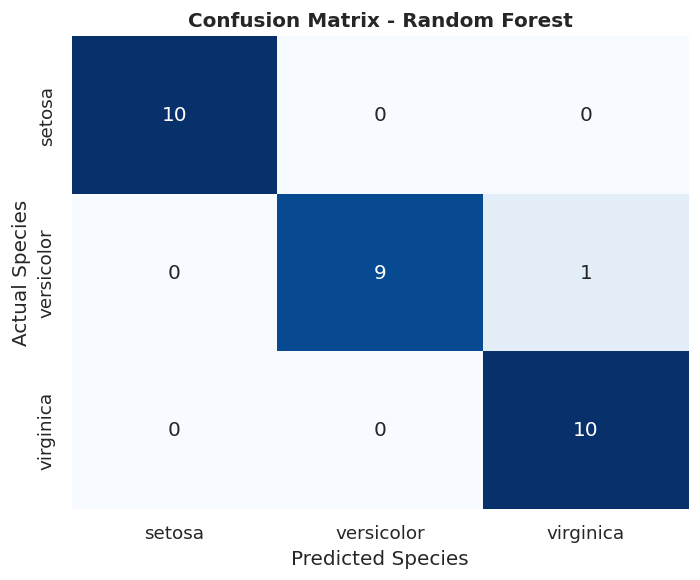

In [3]:
# ==============================================================================
# IRIS SPECIES CLASSIFICATION PIPELINE (WITH FEATURE ENGINEERING & VISUALS)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plot styling for Colab
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# ------------------------------------------------------------------------------
# STEP 1: LOAD DATASET
# ------------------------------------------------------------------------------
print("1. Loading Iris dataset...")
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# ------------------------------------------------------------------------------
# STEP 2: FEATURE ENGINEERING
# ------------------------------------------------------------------------------
print("2. Engineering new morphological features...")
df['sepal_area'] = df['sepal_length'] * df['sepal_width']
df['petal_area'] = df['petal_length'] * df['petal_width']
df['sepal_ratio'] = df['sepal_length'] / df['sepal_width']
df['petal_ratio'] = df['petal_length'] / df['petal_width']
df['petal_to_sepal_area_ratio'] = df['petal_area'] / df['sepal_area']

# Display summary of dataset
print(f"\nDataset Shape: {df.shape}")
print("\nFirst 5 Rows with Engineered Features:")
display(df.head())

# ------------------------------------------------------------------------------
# STEP 3: TRAIN / TEST SPLIT
# ------------------------------------------------------------------------------
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ------------------------------------------------------------------------------
# STEP 4: MODEL EVALUATION & CROSS-VALIDATION
# ------------------------------------------------------------------------------
print("\n3. Training and benchmark evaluation...")
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cv_score = cross_val_score(model, X, y, cv=5).mean()

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "accuracy": acc,
        "cv_score": cv_score
    }

    print(f"\n--- {name} ---")
    print(f"Test Accuracy: {acc:.2%}")
    print(f"5-Fold Cross-Validation Accuracy: {cv_score:.2%}")

# ------------------------------------------------------------------------------
# STEP 5: DETAILED CLASSIFICATION REPORT (BEST MODEL: RANDOM FOREST)
# ------------------------------------------------------------------------------
best_model_name = "Random Forest"
rf_model = results[best_model_name]["model"]
rf_preds = results[best_model_name]["y_pred"]

print(f"\n==================================================")
print(f" Detailed Performance Report: {best_model_name}")
print(f"==================================================")
print(classification_report(y_test, rf_preds))

# ------------------------------------------------------------------------------
# STEP 6: VISUALIZATIONS
# ------------------------------------------------------------------------------

# GRAPH 1: Sepal Area vs Petal Area Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x='sepal_area', y='petal_area',
    hue='species', style='species', s=90, palette='Set1'
)
plt.title('Sepal Area vs. Petal Area by Iris Species', fontsize=12, fontweight='bold')
plt.xlabel('Sepal Area (cm²)')
plt.ylabel('Petal Area (cm²)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

# GRAPH 2: Feature Importances
plt.figure(figsize=(9, 4))
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importances in Species Classification', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# GRAPH 3: Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=iris.target_names, yticklabels=iris.target_names,
    cbar=False
)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.tight_layout()
plt.show()